In [1]:
!pip install requests pandas networkx matplotlib

In [2]:
import requests
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import re
from itertools import combinations
from collections import Counter
from networkx.algorithms.community import greedy_modularity_communities

In [3]:
# Collect the newest 100 posts from r/MachineLearning
url = "https://www.reddit.com/r/MachineLearning/new.json?limit=100"

headers = {
    "User-Agent": "network-analysis-project"
}

response = requests.get(url, headers=headers)

# Check whether request was successful
print("Status code:", response.status_code)

data = response.json()

posts = []

for post in data["data"]["children"]:
    posts.append({
        "post_id": post["data"]["id"],
        "title": post["data"]["title"],
        "author": post["data"]["author"],
        "created_utc": post["data"]["created_utc"],
        "num_comments": post["data"]["num_comments"],
        "score": post["data"]["score"]
    })

posts_df = pd.DataFrame(posts)

print("Total posts collected:", len(posts_df))
posts_df.head()

Status code: 200
Total posts collected: 100


,post_id,title,author,created_utc,num_comments,score
0,1rtsbkv,[P] Karpathy's autoresearch with evolutionary ...,hgarud,1.773516e+09,0,10
1,1rtouwo,[D] Is anyone interested in the RL ↔ Neuroscie...,Kooky_Ad2771,1.773508e+09,11,1
2,1rtled3,[D] Need advice on handling a difficult ACL AR...,Aloo_Ka_Pakoda,1.773500e+09,2,5
3,1rtkazr,[D] ACL ARR 2026 Jan cycle — Does the commitme...,Distinct_Relation129,1.773497e+09,1,2
4,1rtjirw,The arXiv is separating from Cornell Universit...,Benlus,1.773495e+09,68,301


In [4]:
posts_df.to_csv("reddit_posts.csv", index=False)
print("Saved: reddit_posts.csv")

Saved: reddit_posts.csv


In [5]:
# Common words that do not represent meaningful discussion topics
stopwords = {
    "the", "is", "a", "an", "and", "or", "for", "to", "of", "in", "on", "with",
    "how", "what", "why", "best", "using", "use", "used", "from", "about",
    "my", "your", "this", "that", "are", "can", "into", "need", "help",
    "any", "all", "new", "after", "before", "more", "than", "when", "where",
    "which", "who", "should", "would", "could", "their", "there", "them",
    "some", "many", "much", "just", "over", "under", "also", "have", "has",
    "had", "was", "were", "being", "been", "do", "does", "did", "i", "we",
    "you", "they", "it", "our", "me", "us"
}

def extract_keywords(title):
    """
    Convert a Reddit title into a cleaned list of keywords.
    Steps:
    1. Lowercase the text
    2. Keep only alphabetic words
    3. Remove stopwords
    4. Remove very short words
    5. Remove duplicates within the same title
    """
    words = re.findall(r"\b[a-zA-Z]+\b", str(title).lower())
    words = [w for w in words if w not in stopwords and len(w) > 2]
    return sorted(list(set(words)))

In [6]:
# Extract keywords for each post
posts_df["keywords"] = posts_df["title"].apply(extract_keywords)

# Remove posts with no keywords
posts_df = posts_df[posts_df["keywords"].map(len) > 0].reset_index(drop=True)

print("Posts remaining after keyword extraction:", len(posts_df))
posts_df[["post_id", "title", "keywords"]].head(10)


Posts remaining after keyword extraction: 100


,post_id,title,keywords
0,1rtsbkv,[P] Karpathy's autoresearch with evolutionary ...,"[autoresearch, database, evolutionary, karpathy]"
1,1rtouwo,[D] Is anyone interested in the RL ↔ Neuroscie...,"[anyone, deep, dive, interested, neuroscience,..."
2,1rtled3,[D] Need advice on handling a difficult ACL AR...,"[acl, advice, arr, difficult, handling, situat..."
3,1rtkazr,[D] ACL ARR 2026 Jan cycle — Does the commitme...,"[acl, arr, chosen, commitment, cycle, during, ..."
4,1rtjirw,The arXiv is separating from Cornell Universit...,"[arxiv, ceo, cornell, decades, establishing, f..."
5,1rth86s,[D] Reported our meta-reviewer in this ARR cyc...,"[acl, arr, commit, cycle, doc, explaining, mar..."
6,1rt8t19,[D] Has interpretability research been applied...,"[applied, interpretability, model, research, t..."
7,1rt4lyd,[D] ran controlled experiments on meta's COCON...,"[actually, coconut, controlled, experiments, f..."
8,1rsxqoi,[R] biomarker peak detection using machine lea...,"[biomarker, collaborate, detection, learning, ..."
9,1rsxlg8,[P] ColQwen3.5-v2 4.5B is out!,[out]


In [7]:
# Create a bipartite edge list:
# one edge means one post contains one keyword

edge_rows = []

for _, row in posts_df.iterrows():
    post_id = row["post_id"]
    for kw in row["keywords"]:
        edge_rows.append({
            "post_id": post_id,
            "keyword": kw
        })

post_keyword_edges_df = pd.DataFrame(edge_rows)

print("Total post-keyword edges:", len(post_keyword_edges_df))
post_keyword_edges_df.head(10)

Total post-keyword edges: 792


,post_id,keyword
0,1rtsbkv,autoresearch
1,1rtsbkv,database
2,1rtsbkv,evolutionary
3,1rtsbkv,karpathy
4,1rtouwo,anyone
5,1rtouwo,deep
6,1rtouwo,dive
7,1rtouwo,interested
8,1rtouwo,neuroscience
9,1rtouwo,series


In [8]:
post_keyword_edges_df.to_csv("reddit_post_keyword_edges.csv", index=False)
print("Saved: reddit_post_keyword_edges.csv")

Saved: reddit_post_keyword_edges.csv


RQ1: What are the most frequently discussed topics in Reddit Machine Learning posts?

In [9]:
# Show most frequent keywords
all_keywords = [kw for keywords in posts_df["keywords"] for kw in keywords]
keyword_counts = Counter(all_keywords)

top_keywords_df = pd.DataFrame(
    keyword_counts.items(),
    columns=["keyword", "frequency"]
).sort_values(by="frequency", ascending=False)

print("Top 20 most frequent keywords:")
top_keywords_df.head(20)


Top 20 most frequent keywords:


,keyword,frequency
95,open,9
94,llm,8
100,source,6
169,based,6
65,actually,5
179,models,5
62,model,5
15,arr,5
128,papers,5
13,acl,4


In [10]:
# If two keywords appear in the same post title,
# they are connected in the keyword network.

keyword_pair_counts = Counter()

for keywords in posts_df["keywords"]:
    unique_keywords = sorted(set(keywords))
    if len(unique_keywords) >= 2:
        for pair in combinations(unique_keywords, 2):
            keyword_pair_counts[pair] += 1

keyword_network_rows = []

for (kw1, kw2), weight in keyword_pair_counts.items():
    keyword_network_rows.append({
        "source": kw1,
        "target": kw2,
        "weight": weight
    })

keyword_network_edges_df = pd.DataFrame(keyword_network_rows)

print("Total keyword-keyword edges:", len(keyword_network_edges_df))
keyword_network_edges_df.head(10)

Total keyword-keyword edges: 3386


,source,target,weight
0,autoresearch,database,1
1,autoresearch,evolutionary,1
2,autoresearch,karpathy,1
3,database,evolutionary,1
4,database,karpathy,1
5,evolutionary,karpathy,1
6,anyone,deep,1
7,anyone,dive,1
8,anyone,interested,1
9,anyone,neuroscience,1


In [11]:
# Keep only stronger keyword connections
# We can change the threshold if needed

filtered_keyword_edges_df = keyword_network_edges_df[
    keyword_network_edges_df["weight"] >= 2
].reset_index(drop=True)

print("Filtered keyword-keyword edges:", len(filtered_keyword_edges_df))
filtered_keyword_edges_df.head(10)

Filtered keyword-keyword edges: 39


,source,target,weight
0,acl,arr,4
1,acl,cycle,2
2,acl,jan,2
3,arr,cycle,2
4,arr,jan,2
5,arr,meta,2
6,arr,reviews,2
7,meta,reviews,2
8,interpretability,model,2
9,model,training,2


In [12]:
filtered_keyword_edges_df.to_csv("reddit_keyword_network_edges.csv", index=False)
print("Saved: reddit_keyword_network_edges.csv")

Saved: reddit_keyword_network_edges.csv


In [13]:
# Build keyword graph
G = nx.from_pandas_edgelist(
    filtered_keyword_edges_df,
    source="source",
    target="target",
    edge_attr="weight",
    create_using=nx.Graph()
)

print("Number of keyword nodes:", G.number_of_nodes())
print("Number of keyword edges:", G.number_of_edges())

Number of keyword nodes: 35
Number of keyword edges: 39


In [14]:
# Basic network statistics
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
density = nx.density(G)

# Average degree
degrees = dict(G.degree())
avg_degree = sum(degrees.values()) / num_nodes if num_nodes > 0 else 0

print("Network Statistics")
print("------------------")
print("Nodes:", num_nodes)
print("Edges:", num_edges)
print("Density:", density)
print("Average Degree:", avg_degree)

Network Statistics
------------------
Nodes: 35
Edges: 39
Density: 0.06554621848739496
Average Degree: 2.2285714285714286


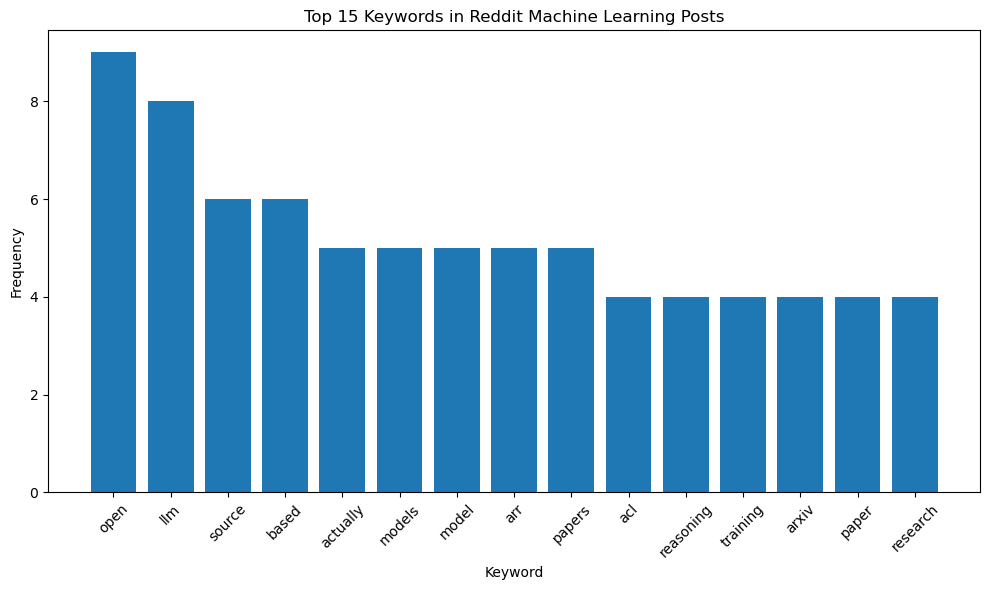

In [15]:
# Visualize keyword frequency distribution
plt.figure(figsize=(10, 6))
plt.bar(top_keywords_df["keyword"].head(15), top_keywords_df["frequency"].head(15))
plt.title("Top 15 Keywords in Reddit Machine Learning Posts")
plt.xlabel("Keyword")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

RQ2: Which keywords are the most influential in the Machine Learning discussion network?

In [16]:
# Community detection
communities = list(greedy_modularity_communities(G))

print("Number of communities detected:", len(communities))
print()

for i, community in enumerate(communities, start=1):
    sample_nodes = list(community)[:10]
    print(f"Community {i}: size = {len(community)}")
    print("Sample keywords:", sample_nodes)
    print()

Number of communities detected: 9

Community 1: size = 8
Sample keywords: ['source', 'project', 'tool', 'open', 'llms', 'leaderboard', 'analysis', 'reasoning']

Community 2: size = 7
Sample keywords: ['real', 'time', 'benchmarking', 'scoring', 'llm', 'papers', 'actually']

Community 3: size = 6
Sample keywords: ['reviews', 'acl', 'jan', 'cycle', 'arr', 'meta']

Community 4: size = 3
Sample keywords: ['training', 'interpretability', 'model']

Community 5: size = 3
Sample keywords: ['tts', 'device', 'swift']

Community 6: size = 2
Sample keywords: ['code', 'paper']

Community 7: size = 2
Sample keywords: ['cvpr', 'workshop']

Community 8: size = 2
Sample keywords: ['fine', 'tuning']

Community 9: size = 2
Sample keywords: ['combining', 'execution']



In [17]:
# Create community mapping
community_map = {}

for i, community in enumerate(communities, start=1):
    for node in community:
        community_map[node] = i

community_df = pd.DataFrame({
    "keyword": list(community_map.keys()),
    "community": list(community_map.values())
})

community_df.head(20)

,keyword,community
0,source,1
1,project,1
2,tool,1
3,open,1
4,llms,1
5,leaderboard,1
6,analysis,1
7,reasoning,1
8,real,2
9,time,2


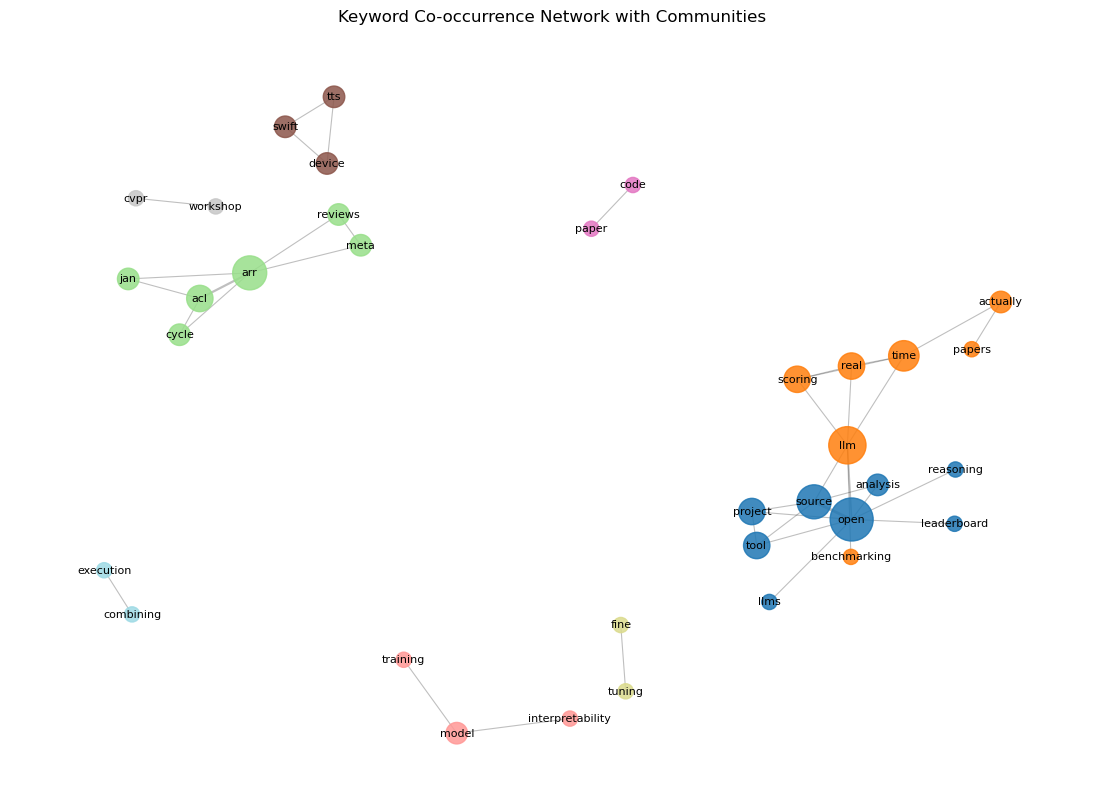

In [18]:
# Visualize keyword network with communities
plt.figure(figsize=(14, 10))

pos = nx.spring_layout(G, seed=42, k=0.5)

node_colors = [community_map[node] for node in G.nodes()]
node_sizes = [G.degree(node) * 120 for node in G.nodes()]

nx.draw_networkx_nodes(
    G,
    pos,
    node_size=node_sizes,
    node_color=node_colors,
    cmap=plt.cm.tab20,
    alpha=0.85
)

edge_widths = [G[u][v]["weight"] * 0.4 for u, v in G.edges()]
nx.draw_networkx_edges(
    G,
    pos,
    width=edge_widths,
    alpha=0.25
)

nx.draw_networkx_labels(
    G,
    pos,
    font_size=8
)

plt.title("Keyword Co-occurrence Network with Communities")
plt.axis("off")
plt.show()

In [19]:
# Degree centrality
degree_centrality = nx.degree_centrality(G)

degree_centrality_df = pd.DataFrame(
    degree_centrality.items(),
    columns=["keyword", "degree_centrality"]
).sort_values(by="degree_centrality", ascending=False)

print("Top 15 keywords by degree centrality:")
degree_centrality_df.head(15)

Top 15 keywords by degree centrality:


,keyword,degree_centrality
11,open,0.235294
10,llm,0.176471
14,source,0.147059
1,arr,0.147059
15,time,0.117647
0,acl,0.088235
18,tool,0.088235
16,project,0.088235
12,real,0.088235
13,scoring,0.088235


In [20]:
# Betweenness centrality
betweenness_centrality = nx.betweenness_centrality(G)

betweenness_df = pd.DataFrame(
    betweenness_centrality.items(),
    columns=["keyword", "betweenness_centrality"]
).sort_values(by="betweenness_centrality", ascending=False)

print("Top 15 keywords by betweenness centrality:")
betweenness_df.head(15)

Top 15 keywords by betweenness centrality:


,keyword,betweenness_centrality
10,llm,0.094474
11,open,0.084670
15,time,0.042781
26,actually,0.023173
14,source,0.020499
1,arr,0.011586
7,model,0.001783
0,acl,0.000891
28,combining,0.000000
27,analysis,0.000000


In [21]:
# PageRank
pagerank_scores = nx.pagerank(G)

pagerank_df = pd.DataFrame(
    pagerank_scores.items(),
    columns=["keyword", "pagerank"]
).sort_values(by="pagerank", ascending=False)

print("Top 15 keywords by PageRank:")
pagerank_df.head(15)

Top 15 keywords by PageRank:


,keyword,pagerank
11,open,0.081571
1,arr,0.054135
10,llm,0.053979
14,source,0.050317
7,model,0.041691
15,time,0.037055
0,acl,0.036352
20,paper,0.028571
21,cvpr,0.028571
23,fine,0.028571


In [22]:
# Combine all centrality measures
centrality_summary_df = degree_centrality_df.merge(
    betweenness_df,
    on="keyword"
).merge(
    pagerank_df,
    on="keyword"
)

centrality_summary_df = centrality_summary_df.sort_values(
    by="pagerank",
    ascending=False
).reset_index(drop=True)

centrality_summary_df.head(20)

,keyword,degree_centrality,betweenness_centrality,pagerank
0,open,0.235294,0.084670,0.081571
1,arr,0.147059,0.011586,0.054135
2,llm,0.176471,0.094474,0.053979
3,source,0.147059,0.020499,0.050317
4,model,0.058824,0.001783,0.041691
5,time,0.117647,0.042781,0.037055
6,acl,0.088235,0.000891,0.036352
7,tuning,0.029412,0.000000,0.028571
8,paper,0.029412,0.000000,0.028571
9,execution,0.029412,0.000000,0.028571


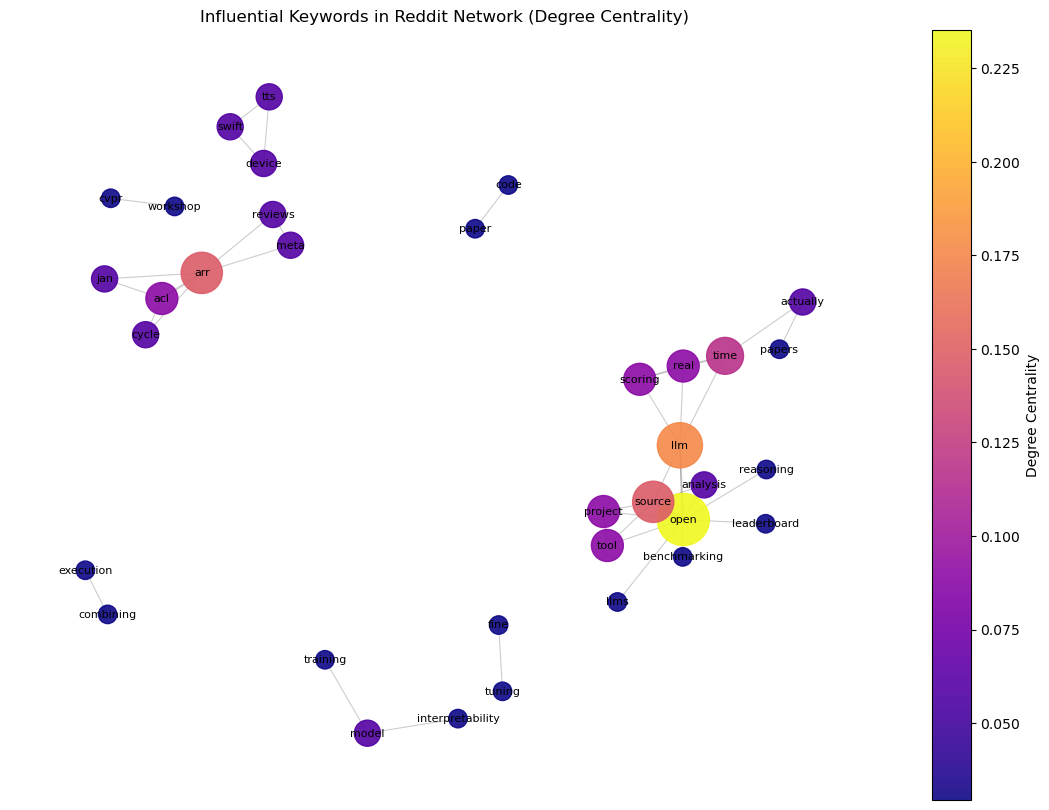

In [23]:
# Visualize degree centrality network
plt.figure(figsize=(14, 10))

pos = nx.spring_layout(G, seed=42, k=0.5)

node_sizes = [degree_centrality[node] * 6000 for node in G.nodes()]
node_colors = [degree_centrality[node] for node in G.nodes()]

nodes = nx.draw_networkx_nodes(
    G,
    pos,
    node_size=node_sizes,
    node_color=node_colors,
    cmap=plt.cm.plasma,
    alpha=0.9
)

edge_widths = [G[u][v]["weight"] * 0.4 for u, v in G.edges()]
nx.draw_networkx_edges(G, pos, width=edge_widths, alpha=0.2)
nx.draw_networkx_labels(G, pos, font_size=8)

plt.colorbar(nodes, label="Degree Centrality")
plt.title("Influential Keywords in Reddit Network (Degree Centrality)")
plt.axis("off")
plt.show()


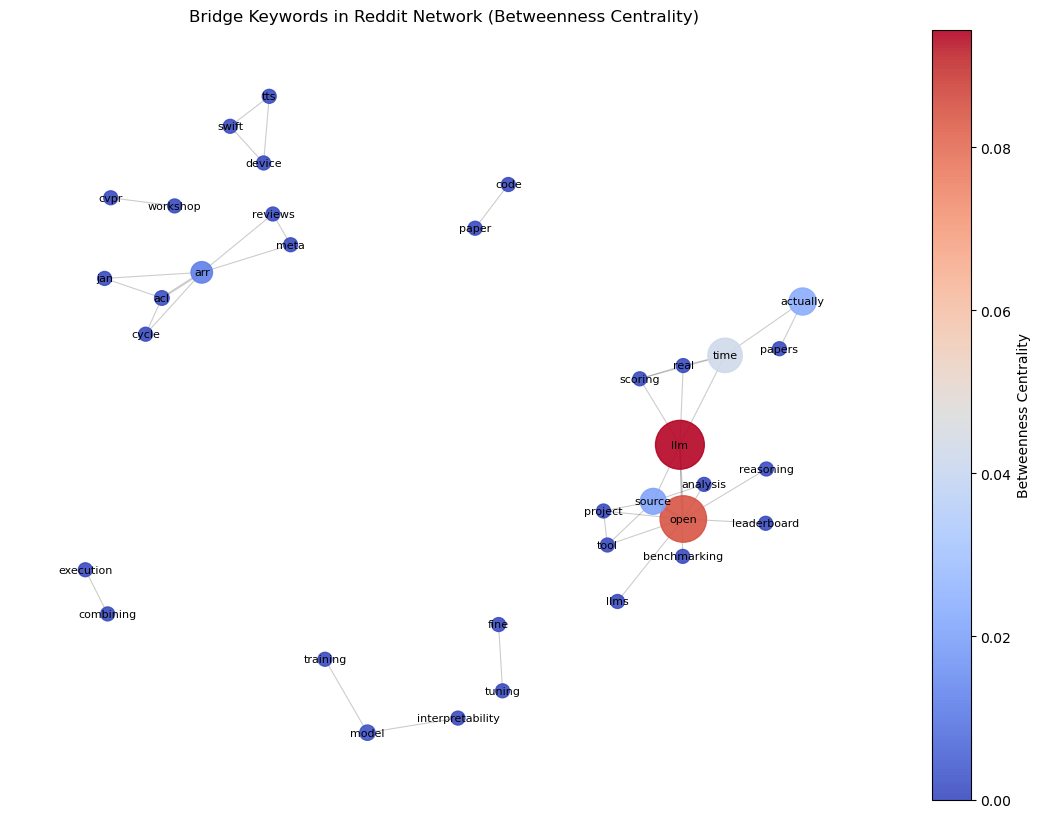

In [24]:
# Visualize betweenness centrality network
plt.figure(figsize=(14, 10))

pos = nx.spring_layout(G, seed=42, k=0.5)

node_sizes = [betweenness_centrality[node] * 12000 + 100 for node in G.nodes()]
node_colors = [betweenness_centrality[node] for node in G.nodes()]

nodes = nx.draw_networkx_nodes(
    G,
    pos,
    node_size=node_sizes,
    node_color=node_colors,
    cmap=plt.cm.coolwarm,
    alpha=0.9
)

edge_widths = [G[u][v]["weight"] * 0.4 for u, v in G.edges()]
nx.draw_networkx_edges(G, pos, width=edge_widths, alpha=0.2)
nx.draw_networkx_labels(G, pos, font_size=8)

plt.colorbar(nodes, label="Betweenness Centrality")
plt.title("Bridge Keywords in Reddit Network (Betweenness Centrality)")
plt.axis("off")
plt.show()


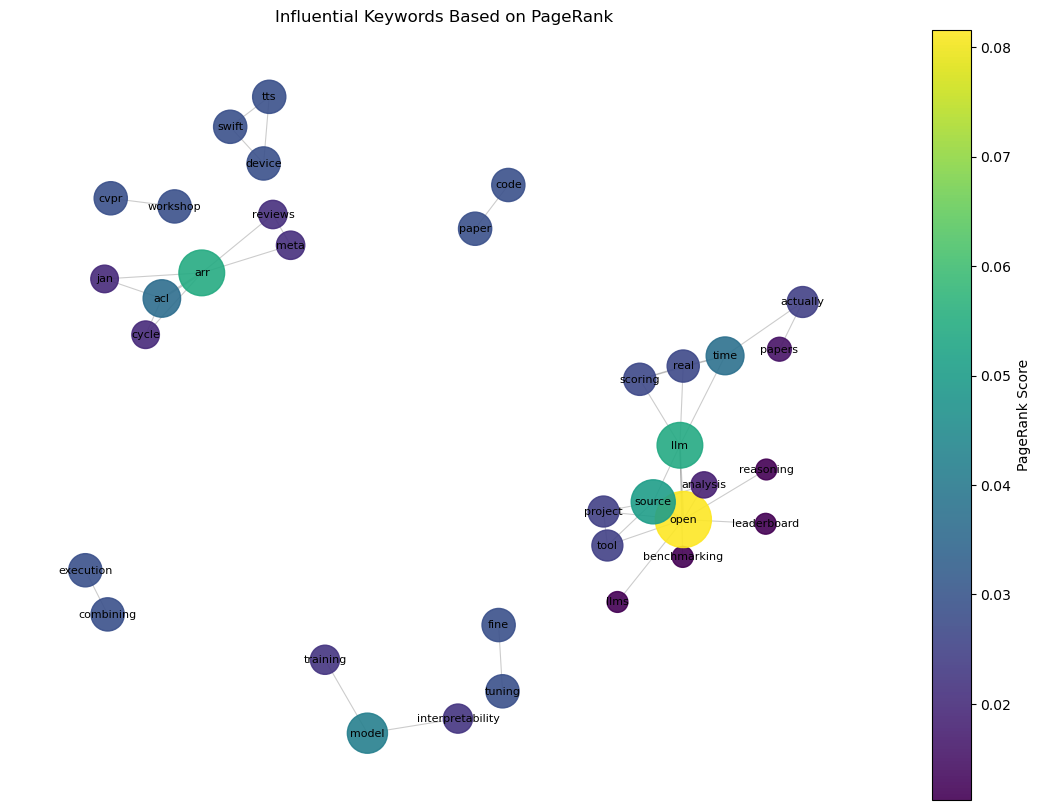

In [25]:
# Visualize PageRank network
plt.figure(figsize=(14, 10))

pos = nx.spring_layout(G, seed=42, k=0.5)

node_sizes = [pagerank_scores[node] * 20000 for node in G.nodes()]
node_colors = [pagerank_scores[node] for node in G.nodes()]

nodes = nx.draw_networkx_nodes(
    G,
    pos,
    node_size=node_sizes,
    node_color=node_colors,
    cmap=plt.cm.viridis,
    alpha=0.9
)

edge_widths = [G[u][v]["weight"] * 0.4 for u, v in G.edges()]
nx.draw_networkx_edges(G, pos, width=edge_widths, alpha=0.2)
nx.draw_networkx_labels(G, pos, font_size=8)

plt.colorbar(nodes, label="PageRank Score")
plt.title("Influential Keywords Based on PageRank")
plt.axis("off")
plt.show()

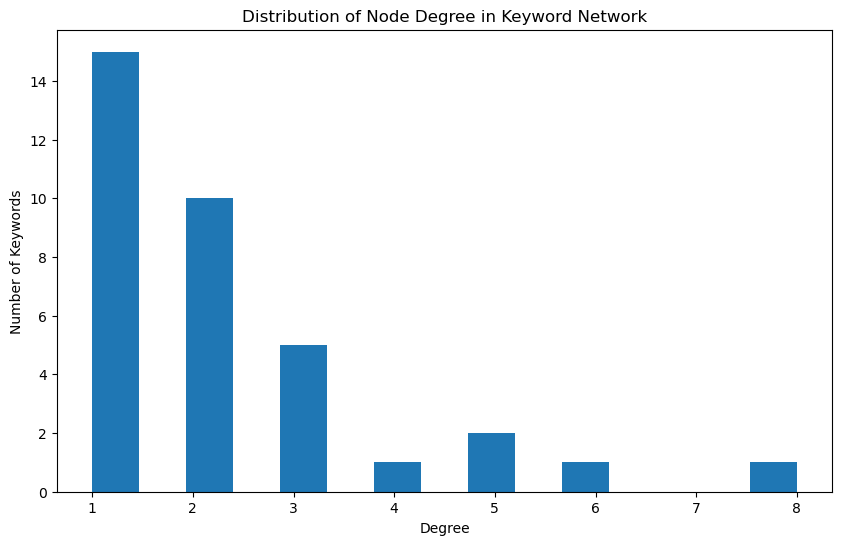

In [26]:
# Degree distribution histogram
plt.figure(figsize=(10, 6))
plt.hist(list(degrees.values()), bins=15)
plt.title("Distribution of Node Degree in Keyword Network")
plt.xlabel("Degree")
plt.ylabel("Number of Keywords")
plt.show()

In [27]:
# Average clustering coefficient
avg_clustering = nx.average_clustering(G)
print("Average clustering coefficient:", avg_clustering)

Average clustering coefficient: 0.41176870748299316


In [28]:
# Top weighted keyword pairs
top_weighted_edges_df = filtered_keyword_edges_df.sort_values(
    by="weight",
    ascending=False
).reset_index(drop=True)

print("Top 20 strongest keyword pairs:")
top_weighted_edges_df.head(20)

Top 20 strongest keyword pairs:


,source,target,weight
0,open,source,5
1,acl,arr,4
2,llm,open,3
3,project,tool,2
4,real,time,2
5,scoring,time,2
6,source,tool,2
7,code,paper,2
8,cvpr,workshop,2
9,fine,tuning,2


In [29]:
# Export results tables
top_keywords_df.to_csv("top_keywords_frequency.csv", index=False)
community_df.to_csv("keyword_communities.csv", index=False)
centrality_summary_df.to_csv("keyword_centrality_summary.csv", index=False)

print("Saved result tables:")
print("- top_keywords_frequency.csv")
print("- keyword_communities.csv")
print("- keyword_centrality_summary.csv")

Saved result tables:
- top_keywords_frequency.csv
- keyword_communities.csv
- keyword_centrality_summary.csv


In [30]:
# Final interpretation printout
print("Final Summary")
print("-------------")
print(f"Posts collected: {len(posts_df)}")
print(f"Keyword nodes: {G.number_of_nodes()}")
print(f"Keyword edges: {G.number_of_edges()}")
print(f"Number of communities: {len(communities)}")
print(f"Average clustering coefficient: {avg_clustering:.4f}")

print("\nTop 10 keywords by PageRank:")
print(centrality_summary_df[["keyword", "pagerank"]].head(10))

Final Summary
-------------
Posts collected: 100
Keyword nodes: 35
Keyword edges: 39
Number of communities: 9
Average clustering coefficient: 0.4118

Top 10 keywords by PageRank:
     keyword  pagerank
0       open  0.081571
1        arr  0.054135
2        llm  0.053979
3     source  0.050317
4      model  0.041691
5       time  0.037055
6        acl  0.036352
7     tuning  0.028571
8      paper  0.028571
9  execution  0.028571
